In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import tilt_distance_Li, plot_tilt_method, bearing

sample_eddies = list(range(1,9))
sample_eddies


[1, 2, 3, 4, 5, 6, 7, 8]

In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]

# Unique colors for each eddy
colors = [c for i, c in enumerate(plt.get_cmap("tab10").colors) if i != 7]


In [3]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')


In [4]:
dic_vert = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/dic_vert_doppio_AMEDA.pkl')
dic_sample = {}
for eddy in sample_eddies:
    dic_sample[f'Eddy{eddy}'] = dic_vert[f'Eddy{eddy}']
    

In [5]:
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_tilt_sample_AMEDA.pkl')
df_ameda = df_ameda.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)


In [6]:
def quad_solver_x(xc, yc, q11, q12, q22, Rc, y0):
    a = q11
    b = -2*q11*xc + 2*q12*(y0 - yc)
    c = q11*xc**2 - 2*q12*xc*(y0 - yc) + q22*(y0 - yc)**2 - Rc**2/2

    disc = b*b - 4*a*c
    root1 = np.where(disc >= 0, (-b - np.sqrt(disc)) / (2*a), np.nan)
    root2 = np.where(disc >= 0, (-b + np.sqrt(disc)) / (2*a), np.nan)
    return root1, root2

def quad_solver_y(xc, yc, q11, q12, q22, Rc, x0):
    a = q22
    b = 2*q12*(x0 - xc)
    c = q11*(x0 - xc)**2 - Rc**2/2

    disc = b*b - 4*a*c
    dy1 = np.where(disc >= 0, (-b - np.sqrt(disc)) / (2*a), np.nan)
    dy2 = np.where(disc >= 0, (-b + np.sqrt(disc)) / (2*a), np.nan)
    return yc + dy1, yc + dy2
    
day_idx_p = [10, 10, 10, 10, 
            10, 10, 10, 10]


/scratch/pbs.8111626.kman.restech.unsw.edu.au/ipykernel_77985/1602576191.py:7: RuntimeWarning: invalid value encountered in sqrt
  root1 = np.where(disc >= 0, (-b - np.sqrt(disc)) / (2*a), np.nan)
/scratch/pbs.8111626.kman.restech.unsw.edu.au/ipykernel_77985/1602576191.py:8: RuntimeWarning: invalid value encountered in sqrt
  root2 = np.where(disc >= 0, (-b + np.sqrt(disc)) / (2*a), np.nan)
/scratch/pbs.8111626.kman.restech.unsw.edu.au/ipykernel_77985/1602576191.py:17: RuntimeWarning: invalid value encountered in sqrt
  dy1 = np.where(disc >= 0, (-b - np.sqrt(disc)) / (2*a), np.nan)
/scratch/pbs.8111626.kman.restech.unsw.edu.au/ipykernel_77985/1602576191.py:18: RuntimeWarning: invalid value encountered in sqrt
  dy2 = np.where(disc >= 0, (-b + np.sqrt(disc)) / (2*a), np.nan)
/scratch/pbs.8111626.kman.restech.unsw.edu.au/ipykernel_77985/1602576191.py:7: RuntimeWarning: invalid value encountered in sqrt
  root1 = np.where(disc >= 0, (-b - np.sqrt(disc)) / (2*a), np.nan)
/scratch/pbs.8111

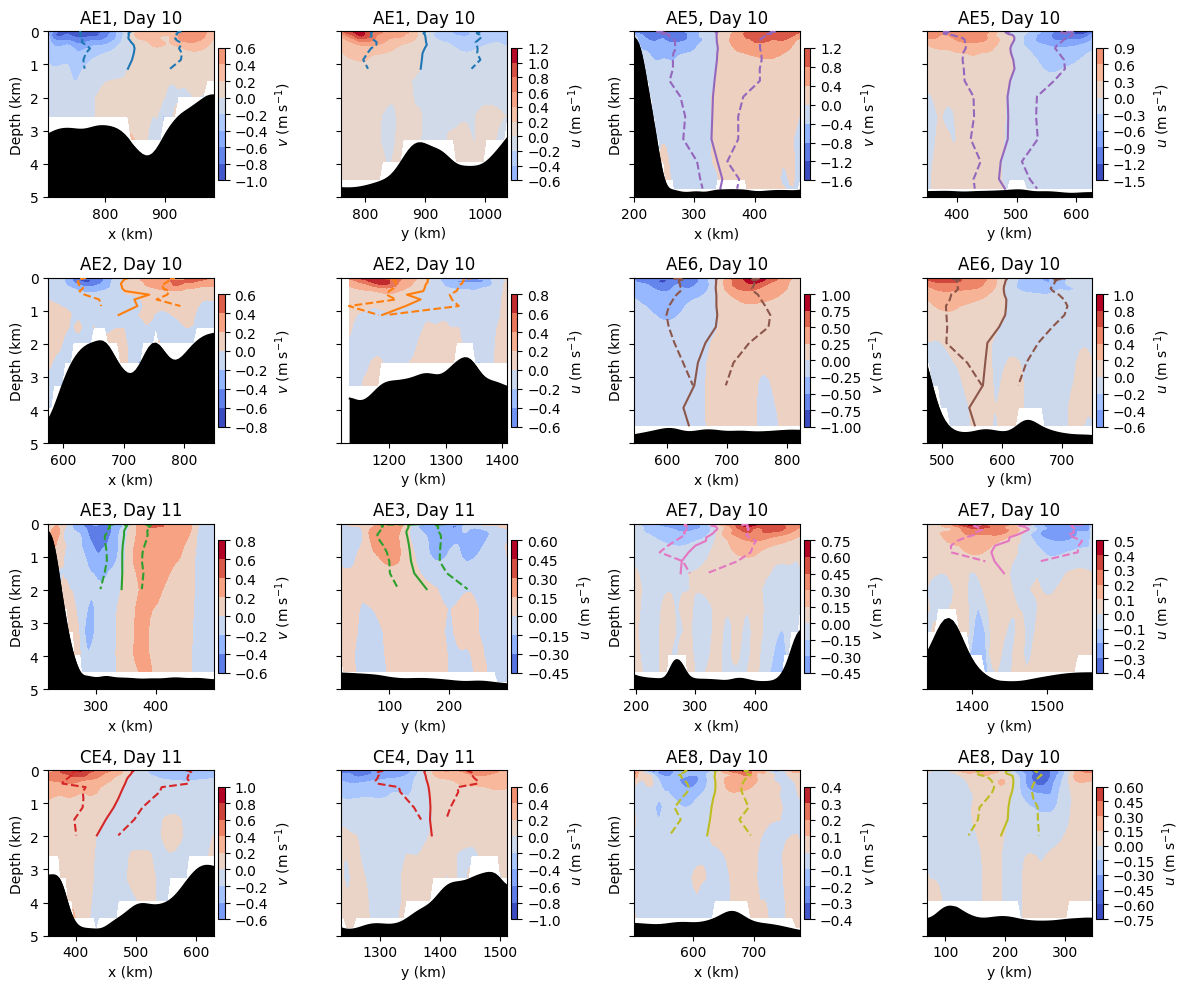

In [7]:
fig, axs = plt.subplots(4, 4, figsize=(12, 10), sharey=True)

fnumber_old = None
u_raw = v_raw = ocean_time = None

for e, (eddy, day_idx) in enumerate(zip(sample_eddies, day_idx_p)):

    if pd.isna(eddy):
        continue

    eddy = int(eddy)
    row = df_ameda.loc[df_ameda.Eddy == eddy].iloc[0]
    cyc = row.Cyc

    ax0 = axs[e % 4, (e // 4) * 2]
    ax1 = axs[e % 4, (e // 4) * 2 + 1]

    r = 200 if eddy in [1780, 1978] else 140
    clr = colors[e % len(colors)]

    dic = dic_sample[f'Eddy{eddy}']
    day_key = list(dic.keys())[day_idx]
    day = int(day_key[3:])
    df = dic[day_key].copy()

    day_rel = day - row.Day
    title = f'{cyc}{eddy}, Day {day_rel}'
    ax0.set_title(title)
    ax1.set_title(title)

    fname = df_ameda.loc[
        (df_ameda.Eddy == eddy) & (df_ameda.Day == day), 'fname'
    ].iloc[0]

    fnumber = fname[-8:-3]

    if fnumber != fnumber_old:
        u_raw = np.load(f'/srv/scratch/z5297792/Climatology/u_v/u_{fnumber}.npy').astype(float)
        v_raw = np.load(f'/srv/scratch/z5297792/Climatology/u_v/v_{fnumber}.npy').astype(float)

        u_raw[np.abs(u_raw) > 1e30] = np.nan
        v_raw[np.abs(v_raw) > 1e30] = np.nan

        with nc.Dataset(fname) as dataset:
            ocean_time = dataset.variables['ocean_time'][:].data / 86400

        fnumber_old = fnumber

    t_rel = np.where(ocean_time == day)[0][0]
    u_t = u_raw[:, :, :, t_rel]
    v_t = v_raw[:, :, :, t_rel]

    xc_surf, yc_surf = df.iloc[0][['xc', 'yc']]

    ic = np.argmin(np.abs(x_grid - xc_surf))
    jc = np.argmin(np.abs(y_grid - yc_surf))

    x_mask = np.abs(x_grid - xc_surf) < r
    y_mask = np.abs(y_grid - yc_surf) < r

    z_km = np.abs(z_r[150, 150, :]) / 1e3
    depth_km = df.Depth.abs() / 1e3

    vmax_v = np.nanmax(np.abs(v_t[x_mask, jc, :]))
    vmax_u = np.nanmax(np.abs(u_t[ic, y_mask, :]))

    im0 = ax0.contourf(
        x_grid[x_mask], z_km, v_t[x_mask, jc, :].T,
        cmap='coolwarm', vmin=-vmax_v, vmax=vmax_v, zorder=0
    )

    ax0.plot(df.xc, depth_km, color=clr)

    roots_x = np.array([
        quad_solver_x(
            d.xc, d.yc, d.Q[0, 0], d.Q[1, 0], d.Q[1, 1], d.Rc, y_grid[jc]
        )
        for _, d in df.iterrows()
    ])

    zorder_x = 1 if df.iloc[-1].yc > y_grid[jc] else 3
    ax0.plot(roots_x[:, 0], depth_km, color=clr, ls='--', zorder=zorder_x)
    ax0.plot(roots_x[:, 1], depth_km, color=clr, ls='--', zorder=zorder_x)

    ax0.plot(x_grid[x_mask], h[x_mask, jc] / 1e3, 'k', zorder=2)
    ax0.fill_between(x_grid[x_mask], h[x_mask, jc] / 1e3, 10, color='k', zorder=2)

    ax0.set_xlabel('x (km)')
    ax0.set_ylabel('Depth (km)')

    cbar0 = fig.colorbar(im0, ax=ax0, pad=0.02, shrink=0.8)
    cbar0.set_label(r'$v$ (m s$^{-1}$)')

    im1 = ax1.contourf(
        y_grid[y_mask], z_km, u_t[ic, y_mask, :].T,
        cmap='coolwarm', vmin=-vmax_u, vmax=vmax_u, zorder=0
    )

    ax1.plot(df.yc, depth_km, color=clr)

    roots_y = np.array([
        quad_solver_y(
            d.xc, d.yc, d.Q[0, 0], d.Q[1, 0], d.Q[1, 1], d.Rc, x_grid[ic]
        )
        for _, d in df.iterrows()
    ])

    zorder_y = 1 if df.iloc[-1].xc < x_grid[ic] else 3
    ax1.plot(roots_y[:, 0], depth_km, color=clr, ls='--', zorder=zorder_y)
    ax1.plot(roots_y[:, 1], depth_km, color=clr, ls='--', zorder=zorder_y)

    ax1.plot(y_grid[y_mask], h[ic, y_mask] / 1e3, 'k', zorder=2)
    ax1.fill_between(y_grid[y_mask], h[ic, y_mask] / 1e3, 10, color='k', zorder=2)

    ax1.set_xlabel('y (km)')
    ax1.set_ylim(0, 5)

    cbar1 = fig.colorbar(im1, ax=ax1, pad=0.02, shrink=0.8)
    cbar1.set_label(r'$u$ (m s$^{-1}$)')

axs[0, 0].invert_yaxis()
plt.tight_layout()
plt.show()


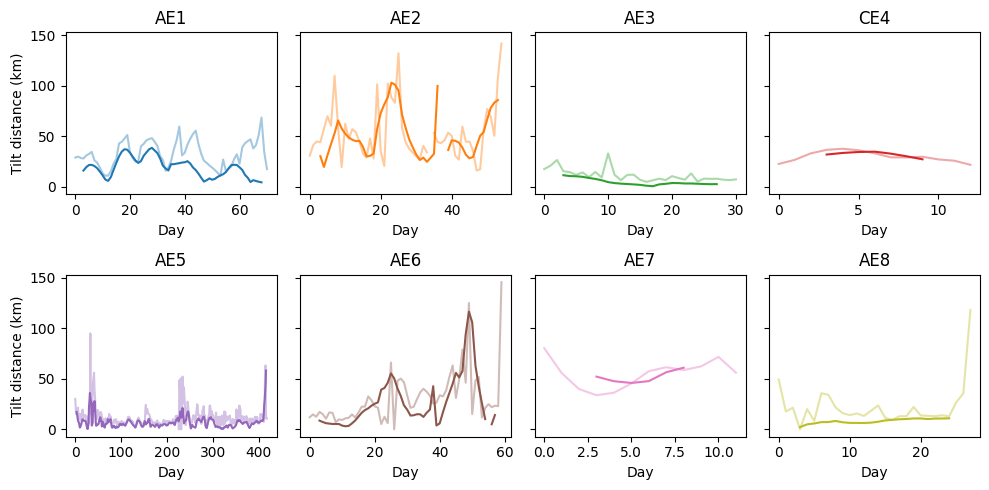

In [8]:
fig, axs = plt.subplots(2, 4, figsize=(10, 5), sharey=True)

for e, eddy in enumerate(dic_sample.keys()):
    ax = axs[e // 4, e % 4]
    dic = dic_sample[eddy]
    days = sorted(dic.keys())
    TDis = []
    for day in days:
        df = dic[day].copy()
        if len(df):
            df = df[df.Depth.abs() < 1e3]
            td, th, _ = tilt_distance_Li(df.xc.values, df.yc.values, df.Depth.abs().values)
            TDis.append(td)
        else:
            TDis.append(np.nan)
    ax.plot(range(len(TDis)), TDis, color=colors[e % 10], alpha=.4)
    df = df_ameda[df_ameda.Eddy==int(eddy[4:])]
    ax.plot(np.arange(len(df)), df.TiltDis, color=colors[e])
    cyc = df_ameda[df_ameda.Eddy==int(eddy[4:])].iloc[0].Cyc
    ax.set_title(f'{cyc}{int(eddy[4:])}')
    ax.set_xlabel('Day')
    # ax.axhline(y=10, color='r')
axs[0,0].set_ylabel('Tilt distance (km)')
axs[1,0].set_ylabel('Tilt distance (km)')

plt.tight_layout()


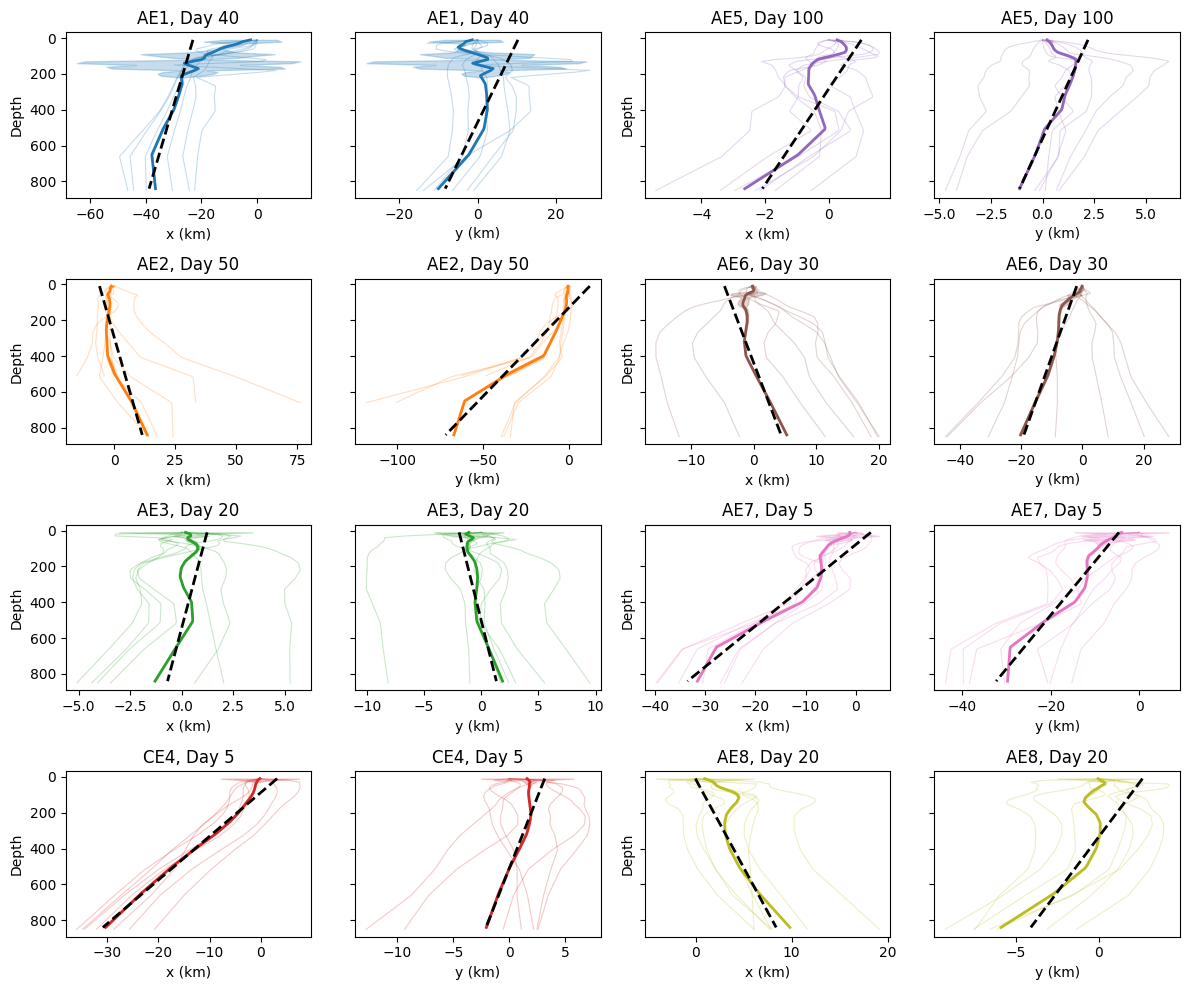

In [12]:
fig, axs = plt.subplots(4, 4, figsize=(12, 10), sharey=True)

ref_days = [40, 50, 20, 5, 100, 30, 5, 20]

for e, (eddy, ref_day) in enumerate(zip(sample_eddies, ref_days)):

    row = e % 4
    col = (e // 4) * 2

    ax_x = axs[row, col]
    ax_y = axs[row, col + 1]

    out = plot_tilt_method(
        dic_all=dic_sample,
        eddy=eddy,
        ref_day_idx=ref_day,
        ax_x=ax_x,
        ax_y=ax_y,
        num=6,
        depth_int=10,
        max_depth=1000,
        min_depth_range=200,
        color=colors[e],
        show=False
    )

    if out[0] is None:
        ax_x.text(0.5, 0.5, f'Eddy {eddy}\nnot measurable',
                  ha='center', va='center', transform=ax_x.transAxes)
        ax_y.text(0.5, 0.5, f'Eddy {eddy}\nnot measurable',
                  ha='center', va='center', transform=ax_y.transAxes)
        continue

    cyc = df_ameda[df_ameda.Eddy==eddy].iloc[0].Cyc
    ax_x.set_title(f'{cyc}{eddy}, Day {ref_day}')
    ax_y.set_title(f'{cyc}{eddy}, Day {ref_day}')
    ax_x.get_legend().remove()
    ax_x.set_xlabel('x (km)'); ax_y.set_xlabel('y (km)')
axs[0,0].invert_yaxis()

for ax in axs[:, 0]:
    ax.set_ylabel('Depth')

# for ax in axs[-1, :]:
#     ax.set_xlabel('Displacement')

plt.tight_layout()
plt.show()


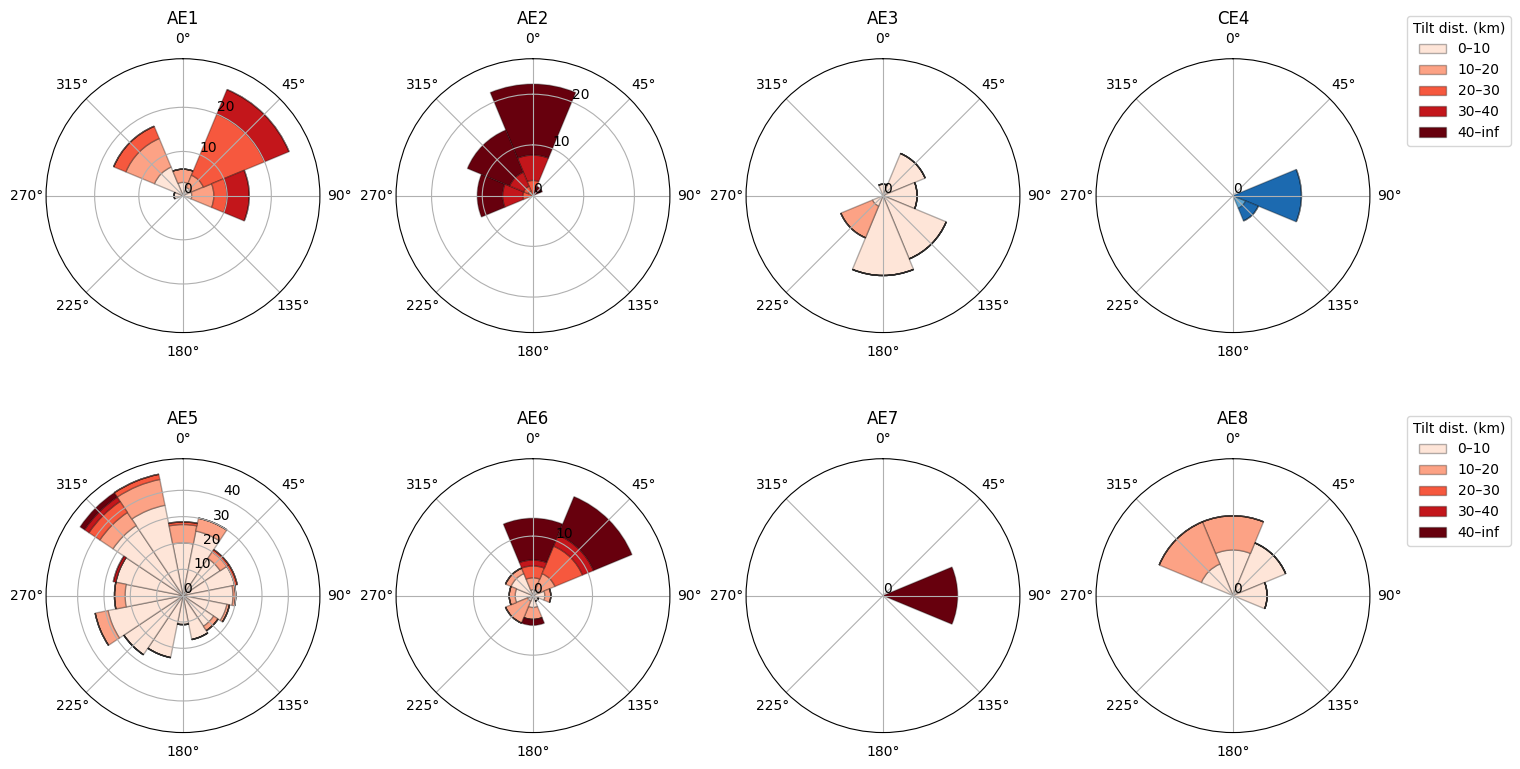

In [13]:
def choose_dir_bins_cardinal(*dfs, col='TiltDir', min_bins=8, max_bins=36, min_avg_per_sector=8):
    candidates = np.array([4, 6, 8, 9, 10, 12, 15, 16, 18, 20, 24, 30, 36, 45, 60, 72])
    candidates = candidates[(candidates >= min_bins) & (candidates <= max_bins)]
    candidates = candidates[candidates % 4 == 0]

    Ns = []
    for df in dfs:
        x = df[col].to_numpy()
        x = x[np.isfinite(x)]
        Ns.append(x.size)
    N = min(Ns) if Ns else 0

    if N == 0 or candidates.size == 0:
        k = 16
    else:
        k0 = int(np.ceil(2 * N ** (1/3)))
        k = candidates[np.argmin(np.abs(candidates - k0))]
        while k > candidates.min() and (N / k) < min_avg_per_sector:
            k = candidates[candidates < k].max()

    dir_bins = np.linspace(0.0, 360.0, k + 1)
    shift = 180.0 / k
    return dir_bins, shift

# ---- per-eddy windroses (bins chosen per panel) ----
fig, axs = plt.subplots(
    2, 4, figsize=(14, 8),
    subplot_kw={'projection': 'polar'},
    constrained_layout=True
)
axs = axs.flatten()

sample_eddies_8 = sample_eddies[:8]
mag_bins = [0, 10, 20, 30, 40, np.inf]

colors_AE = plt.cm.Reds(np.linspace(0.1, 1, len(mag_bins) - 1))
colors_CE = plt.cm.Blues(np.linspace(0.1, 1, len(mag_bins) - 1))

for ax, eddy in zip(axs, sample_eddies_8):
    df = df_ameda[df_ameda.Eddy == eddy].copy()

    directions = np.mod(df.TiltDir.to_numpy(), 360.0)
    magnitudes = df.TiltDis.to_numpy()
    m = np.isfinite(directions) & np.isfinite(magnitudes)
    directions = directions[m]
    magnitudes = magnitudes[m]

    cyc = df.iloc[0].Cyc if len(df) else ""
    colorss = colors_AE if cyc == "AE" else colors_CE

    # --- choose direction bins for THIS eddy only ---
    dir_bins, dir_shift = choose_dir_bins_cardinal(df, col='TiltDir', min_bins=8, max_bins=36, min_avg_per_sector=6)
    k = len(dir_bins) - 1
    binw_deg = 360.0 / k
    angles = np.deg2rad(np.arange(k) * binw_deg)
    width = np.deg2rad(binw_deg)

    directions_s = np.mod(directions + dir_shift, 360.0)
    dir_idx = np.digitize(directions_s, dir_bins, right=False) - 1
    mag_idx = np.digitize(magnitudes, mag_bins, right=False) - 1

    counts = np.zeros((len(mag_bins) - 1, k))
    for d_i, m_i in zip(dir_idx, mag_idx):
        if 0 <= d_i < k and 0 <= m_i < (len(mag_bins) - 1):
            counts[m_i, d_i] += 1

    bottom = np.zeros(k)
    for i in range(counts.shape[0]):
        ax.bar(
            angles, counts[i], width,
            bottom=bottom,
            color=colorss[i],
            edgecolor=(0, 0, 0, 0.3),
            label=f'{mag_bins[i]:g}–{mag_bins[i+1]:g}'
        )
        bottom += counts[i]
    rmax = bottom.max()
    ax.set_rlim(0, rmax + 5)
    ax.set_rticks(np.arange(0, rmax + 1, 10))
    ax.set_title(f'{cyc}{eddy}')# (k={k})')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.08, 0.98), title='Tilt dist. (km)')

handles, labels = axs[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.08, 0.48), title='Tilt dist. (km)')

plt.show()
